# Telecom Customer Churn Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="whitegrid")

In [3]:
df=pd.read_csv(r"C:\Users\Aditi\Downloads\Customer_churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning & Formatting

In [7]:
df.rename(columns={
    'customerID': 'customer_id',
    'gender': 'gender',
    'SeniorCitizen': 'senior_citizen',
    'Partner': 'partner',
    'Dependents': 'dependents',
    'tenure': 'tenure',
    'PhoneService': 'phone_service',
    'MultipleLines': 'multiple_lines',
    'InternetService': 'internet_service',
    'OnlineSecurity': 'online_security',
    'OnlineBackup': 'online_backup',
    'DeviceProtection': 'device_protection',
    'TechSupport': 'tech_support',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_movies',
    'Contract': 'contract',
    'PaperlessBilling': 'paperless_billing',
    'PaymentMethod': 'payment_method',
    'MonthlyCharges': 'monthly_charges',
    'TotalCharges': 'total_charges',
    'Churn': 'churn'
}, inplace=True);

In [8]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.isnull().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering
- Converted total_charges to float data type
- Created columns tenure_group, charges_group and total_services for better analysis
- Mapped senior_citizens from bool from 0,1 to yes, no

In [11]:
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

In [13]:
df['tenure_group']= pd.cut(df['tenure'], bins= [0,12,24,48,72], labels=['0-1yr','1-2yr','2-4yr', '4+yr'])

In [14]:
df['charges_group']= pd.cut(df['monthly_charges'], bins= [0,35,70,100,130], labels=['Low', 'Medium','High', 'Very High'])

In [15]:
services= ['phone_service', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']
df['total_services'] = df[services].apply(lambda x: x.eq('Yes').sum(), axis=1)

In [16]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,tenure_group,charges_group,total_services
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1yr,Low,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,2-4yr,Medium,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1yr,Medium,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4yr,Medium,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1yr,High,1


In [17]:
df['senior_citizen'] = df['senior_citizen'].map({0:'No', 1:'Yes'})

## Customer Segmentation (RFM Analysis)

In [18]:
df['R_score'] = pd.qcut(df['tenure'], 3, labels=[1,2,3])
df['F_score'] = pd.qcut(df['total_services'], 3, labels=[1,2,3])
df['M_score'] = pd.qcut(df['total_charges'], 3, labels=[1,2,3])

In [19]:
df[['R_score','F_score','M_score']].isna().sum()

R_score     0
F_score     0
M_score    11
dtype: int64

In [20]:
df['M_score']= df['M_score'].cat.add_categories([0]).fillna(0)

In [21]:
df['RFM_score'] = df['R_score'].astype(int) + df['F_score'].astype(int) + df['M_score'].astype(int)

In [22]:
def segment(score):
    if score >= 7:
        return "High Value"
    elif score >= 4:
        return "Medium Value"
    else:
        return "Low Value"

df['customer_segment'] = df['RFM_score'].apply(segment)

In [23]:
R_score, bins = pd.qcut(df['tenure'], 3, labels=[1,2,3], retbins=True)
print(bins)

[ 0. 14. 47. 72.]


In [24]:
F_score, bins = pd.qcut(df['total_services'], 3, labels=[1,2,3], retbins=True)
print(bins)

[0. 2. 4. 7.]


In [25]:
M_score, bins = pd.qcut(df['total_charges'], 3, labels=[1,2,3], retbins=True)
print(bins)

[  18.8         678.36666667 2745.36666667 8684.8       ]


In [26]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,total_charges,churn,tenure_group,charges_group,total_services,R_score,F_score,M_score,RFM_score,customer_segment
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,29.85,No,0-1yr,Low,1,1,1,1,3,Low Value
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,1889.50,No,2-4yr,Medium,3,2,2,2,6,Medium Value
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,108.15,Yes,0-1yr,Medium,3,1,2,1,4,Medium Value
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,1840.75,No,2-4yr,Medium,3,2,2,2,6,Medium Value
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,151.65,Yes,0-1yr,High,1,1,1,1,3,Low Value


In [27]:
df['customer_segment'].value_counts()

customer_segment
Medium Value    2962
High Value      2508
Low Value       1573
Name: count, dtype: int64

In [28]:
df.groupby('customer_segment')['churn'].value_counts()

customer_segment  churn
High Value        No       2097
                  Yes       411
Low Value         No        892
                  Yes       681
Medium Value      No       2185
                  Yes       777
Name: count, dtype: int64

In [29]:
df.groupby('customer_segment')['total_charges'].sum()

customer_segment
High Value      12251746.25
Low Value         273302.05
Medium Value     3531120.40
Name: total_charges, dtype: float64

## Insight
- High-value customers contribute the most to total revenue and show lower churn rates.
- Low-value customers are more likely to churn, indicating low engagement and retention.
- Medium-value customers form a transition group and can be targeted to improve retention.

## EDA

## Churn Distribution

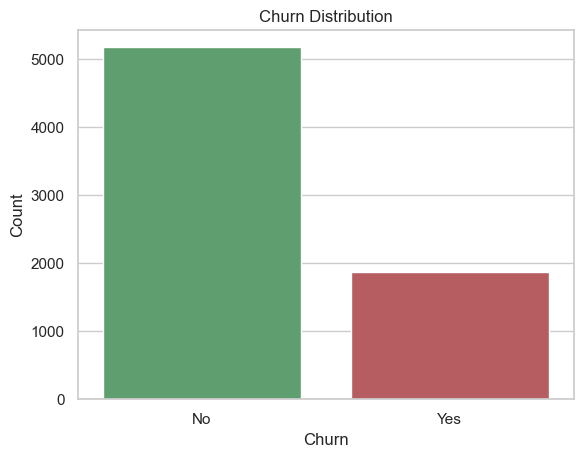

In [30]:
sns.countplot(x='churn', data=df, hue='churn', legend=False, palette={'Yes':'r','No':'g'})
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

## Churn by Gender

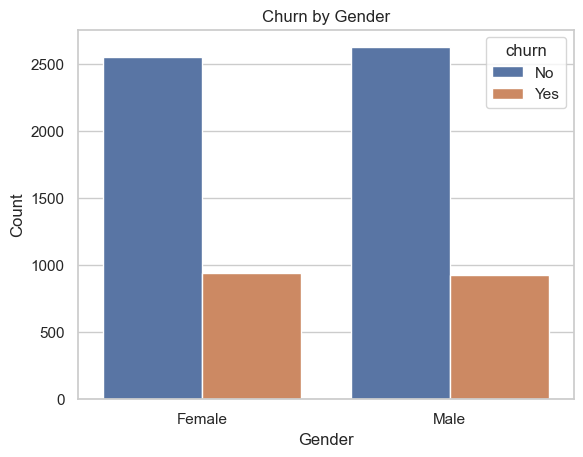

In [31]:
sns.countplot(x='gender' , hue='churn', data=df)
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## Churn by Contract 

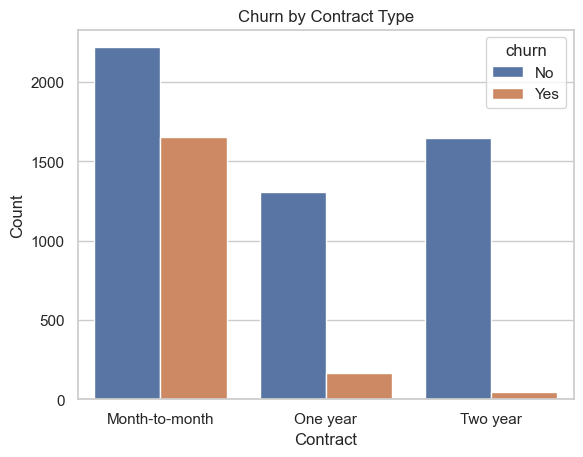

In [32]:
sns.countplot(x='contract', hue='churn', data=df)
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.show()

## Insight
Customers with month-to-month contracts exhibit significantly higher churn compared to one-year and two-year contracts, indicating lower commitment leads to higher churn.

## Churn by Payment Method

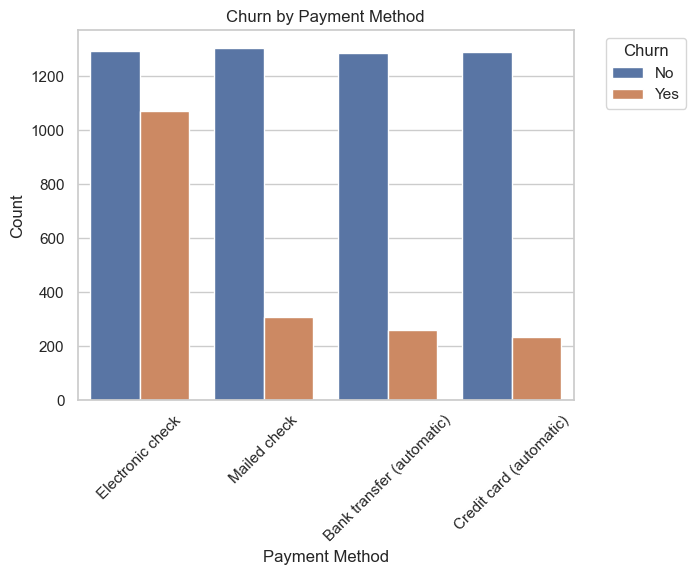

In [33]:
sns.countplot(x='payment_method', hue='churn', data=df)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Churn", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Insight
Customers using Electronic check as a payment method show the highest churn, suggesting possible dissatisfaction or inconvenience with this mode.

## Churn by Tenure

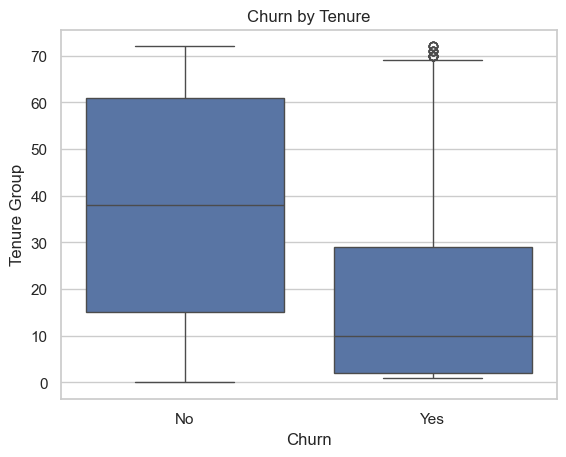

In [34]:
sns.boxplot(x='churn', y='tenure', data=df)
plt.title("Churn by Tenure")
plt.xlabel("Churn")
plt.ylabel("Tenure Group")
plt.show()

## Insight
-Customers who churn have significantly lower median tenure compared to retained customers.
-Most churned customers fall within the early tenure range, confirming that new customers are more likely to leave.
-Retained customers show a wider and higher tenure distribution, indicating strong loyalty over time
-Outliers at 71-72 months, a few long term customers also churned but its very rare 

## Churn by Tenure Group 

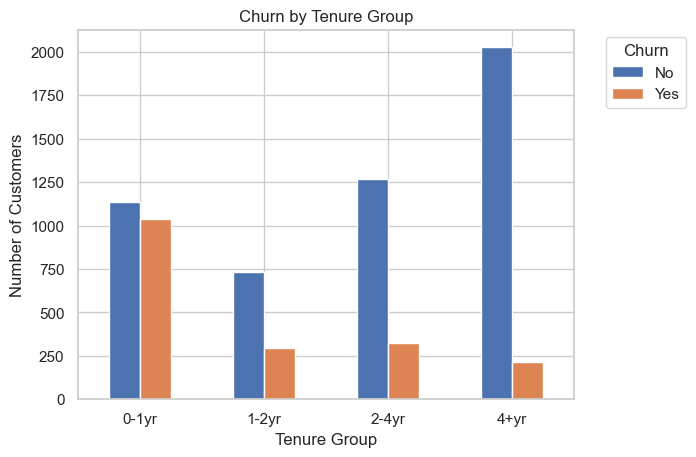

In [35]:
df.groupby('tenure_group', observed=True)['churn'].value_counts().unstack().plot(kind='bar')

plt.title('Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title="Churn", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Insight
Churn is highest among customers with less than one year of tenure and gradually decreases as tenure increases, highlighting the importance of early customer retention.

## Churn by Total Services

<function matplotlib.pyplot.show(close=None, block=None)>

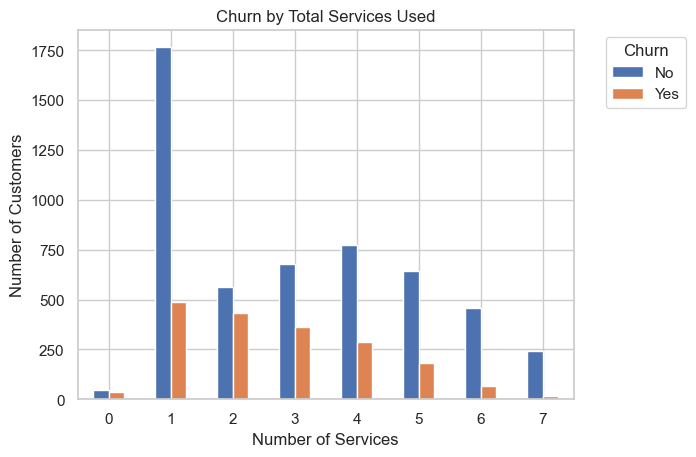

In [36]:
df.groupby('total_services')['churn'].value_counts().unstack().plot(kind='bar')
plt.title('Churn by Total Services Used')
plt.xlabel('Number of Services')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title="Churn", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show

## Insight
Customers using fewer services are more likely to churn, while those with more services tend to stay, indicating higher engagement reduces churn.

## Tenure Vs Monthly Charges

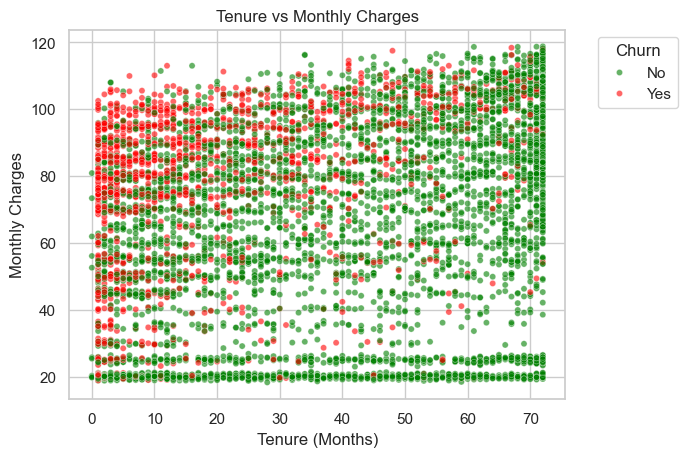

In [37]:
sns.scatterplot(x='tenure', y='monthly_charges', hue='churn', data=df,   palette={'Yes':'red','No':'green'}, alpha=0.6, s=20)
plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.legend(title="Churn", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Insight
- Customers with low tenure show higher churn across all charge levels, while long-term customers remain stable regardless of monthly charges

## Churn by Charges group 

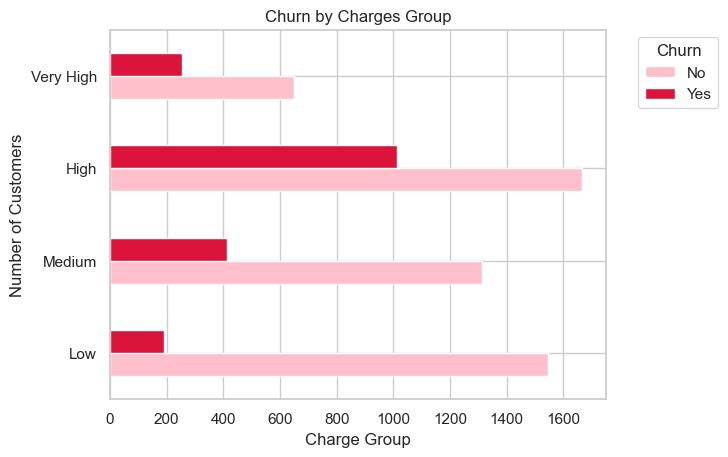

In [38]:
df.groupby('charges_group', observed=True)['churn'].value_counts().unstack().plot(kind='barh',color={'No':'pink','Yes':'crimson'} )
plt.title('Churn by Charges Group')
plt.xlabel('Charge Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title="Churn", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Insight
Customers with **High** monthly charges exhibit the highest churn, followed by medium and very high charge groups, while low-charge customers show the least churn.

## Correlation Heatmap

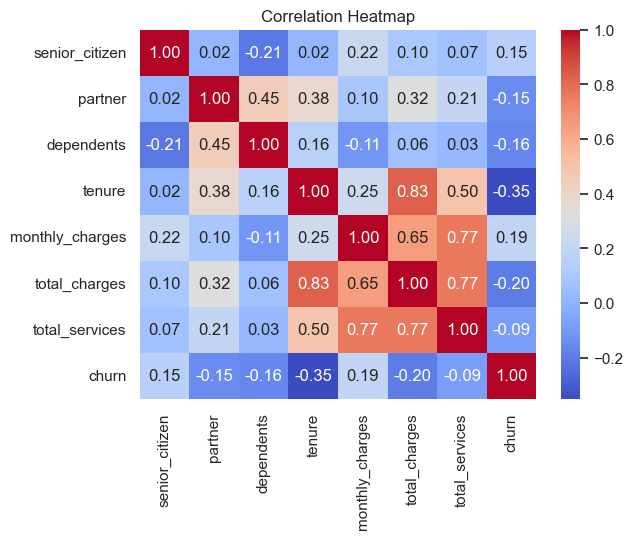

In [39]:
df_corr = df.copy()

df_corr['churn'] = df_corr['churn'].map({'Yes': 1, 'No': 0})
df_corr['partner'] = df_corr['partner'].map({'Yes': 1, 'No': 0})
df_corr['dependents'] = df_corr['dependents'].map({'Yes': 1, 'No': 0})
df_corr['senior_citizen'] = df_corr['senior_citizen'].map({'Yes': 1, 'No': 0})

numeric_cols = ['senior_citizen', 'partner', 'dependents', 'tenure',
                'monthly_charges', 'total_charges', 'total_services', 'churn']
  

sns.heatmap(df_corr[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
  

## Insight
- Tenure is negatively correlated with churn (-0.35), indicating long-term customers are less likely to leave.
- Monthly charges have a slight positive correlation with churn (0.19), suggesting higher-paying customers are somewhat more likely to churn.
- Customers with partners and dependents show a slight negative correlation with churn, suggesting more stable customer profiles.
- Total charges are strongly correlated with tenure (0.83), meaning longer-tenure customers contribute more to overall revenue.

## Export Cleaned data

In [40]:
df.to_csv("Customer_churn_cleaned", index=False)